<a href="https://colab.research.google.com/github/Mahyar-GH79/Advanced-ML_-CSCI-6365/blob/main/assignment1_link_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1: Link Prediction with NASA GES-D

This notebook implements two link prediction approaches on the NASA GES-DISC Knowledge Graph dataset:
1. **Part 1** – Dataset exploration and statistics
2. **Part 2, Method 1** – Embedding-based link prediction (Node2Vec + MLP)
3. **Part 2, Method 2** – Graph-heuristic link prediction (Common Neighbors / Adamic-Adar)
4. **Part 3** – Reflection and comparison


## Setup: Install & Import Dependencies

In [ ]:
# ── Install all dependencies ──────────────────────────────────────────────────
# NOTE: torch-cluster is intentionally skipped here.
# The Node2Vec cell uses a gensim-based fallback that requires no C extensions.
# After this cell finishes → RESTART THE KERNEL before continuing.

import subprocess, sys

def sh(cmd, timeout=180):
    """Run shell command, stream stdout, hard-kill after timeout seconds."""
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True, timeout=timeout)
    if r.stdout:
        print(r.stdout[-1500:])
    if r.returncode != 0:
        print('STDERR:', r.stderr[-800:])

print('1/3  Force-reinstalling numpy + compiled packages ...')
sh('pip install -q --force-reinstall "numpy==1.26.4" pandas scipy scikit-learn matplotlib')
print('  done.')

print('2/3  Installing pure-python packages ...')
# python-louvain installs as 'community' but the import is 'community.best_partition'
# Force-reinstall to avoid conflicts with any other 'community' package already present
sh('pip install -q networkx seaborn requests gensim')
sh('pip install -q --force-reinstall python-louvain')
print('  done.')

print('3/3  Installing torch-geometric (core only, no C extensions needed) ...')
sh('pip install -q torch-geometric')
print('  done.')

print()
print('=' * 60)
print('  DONE.  RESTART THE KERNEL before running any other cell.')
print('  Colab  : Runtime → Restart runtime')
print('  Jupyter: Kernel  → Restart Kernel')
print('=' * 60)

1/3  Force-reinstalling numpy + compiled packages ...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.6/362.6 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 71.5 MB/s eta 0:00

In [ ]:
import os
import time
import requests
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.data import Data
from torch_geometric.utils import from_networkx, negative_sampling

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    accuracy_score, f1_score, confusion_matrix
)
from sklearn.preprocessing import LabelEncoder

print("All imports successful.")
print(f"PyTorch version: {torch.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

All imports successful.
PyTorch version: 2.10.0+cu128
Using device: cuda


---
## Part 1: Exploring the NASA GES-DISC Dataset (20%)

### 1.1 Download the Dataset

In [ ]:
BASE_URL = "https://zenodo.org/records/11492533/files"
FILES = ["nodes.csv", "train_edges.csv", "val_links.csv", "test_links.csv"]
DATA_DIR = "nasa_gesdisc_data"

os.makedirs(DATA_DIR, exist_ok=True)

for fname in FILES:
    fpath = os.path.join(DATA_DIR, fname)
    if not os.path.exists(fpath):
        print(f"Downloading {fname}...")
        r = requests.get(f"{BASE_URL}/{fname}?download=1", timeout=120)
        r.raise_for_status()
        with open(fpath, "wb") as f:
            f.write(r.content)
        print(f"  Saved {fname} ({len(r.content)/1024:.1f} KB)")
    else:
        print(f"{fname} already exists, skipping download.")

print("\nAll files ready.")

  Saved nodes.csv (2850.7 KB)
  Saved train_edges.csv (334.8 KB)
  Saved val_links.csv (8.6 KB)
  Saved test_links.csv (8.6 KB)

All files ready.


### 1.2 Load the Data

In [ ]:
nodes_df      = pd.read_csv(os.path.join(DATA_DIR, "nodes.csv"))
train_df      = pd.read_csv(os.path.join(DATA_DIR, "train_edges.csv"))
val_df        = pd.read_csv(os.path.join(DATA_DIR, "val_links.csv"))
test_df       = pd.read_csv(os.path.join(DATA_DIR, "test_links.csv"))

print("=== nodes.csv ===")
print(nodes_df.head())
print(f"Shape: {nodes_df.shape}")

print("\n=== train_edges.csv ===")
print(train_df.head())
print(f"Shape: {train_df.shape}")

print("\n=== val_links.csv ===")
print(val_df.head())
print(f"Shape: {val_df.shape}")

print("\n=== test_links.csv ===")
print(test_df.head())
print(f"Shape: {test_df.shape}")

=== nodes.csv ===
   id        label                                         properties
0   0  ['Dataset']  {'abstract': 'The Atmospheric Infrared Sounder...
1   1  ['Dataset']  {'abstract': 'Version 07 is the current versio...
2   2  ['Dataset']  {'abstract': 'The Solar Backscattered Ultravio...
3   3  ['Dataset']  {'abstract': 'The data presented in this level...
4   4  ['Dataset']  {'abstract': 'The TROPESS CrIS-SNPP L2 for Sao...
Shape: (5763, 3)

=== train_edges.csv ===
   source  target   relationship_type
0    1152    1354          OF_PROJECT
1    1317    1164         HAS_DATASET
2    1317     768         HAS_DATASET
3    1271   23795  HAS_SCIENCEKEYWORD
4     820   23837  HAS_SCIENCEKEYWORD
Shape: (13820, 3)

=== val_links.csv ===
   source  target
0    1144   23689
1    1016   23689
2    1298   24881
3     348   23780
4     876   23715
Shape: (860, 2)

=== test_links.csv ===
   source  target
0     545   24190
1     867   24623
2     962   23690
3     857   23715
4     242   2

### 1.3 Understand Column Names

In [ ]:
print("nodes.csv columns:", nodes_df.columns.tolist())
print("train_edges.csv columns:", train_df.columns.tolist())
print("val_links.csv columns:", val_df.columns.tolist())
print("test_links.csv columns:", test_df.columns.tolist())

nodes.csv columns: ['id', 'label', 'properties']
train_edges.csv columns: ['source', 'target', 'relationship_type']
val_links.csv columns: ['source', 'target']
test_links.csv columns: ['source', 'target']


### 1.4 Normalise Column Names

The dataset files may use different column name conventions. We normalise them to `node_id`, `node_type`, `source`, `target`, and `label`.

In [ ]:
# ── Nodes ────────────────────────────────────────────────────────────────────

def normalise_nodes(df):
    df = df.copy()
    col_map = {}
    for c in df.columns:
        if c.lower() in ('id', 'node_id', 'nodeid'):
            col_map[c] = 'node_id'
        elif c.lower() in ('type', 'node_type', 'nodetype', 'label', 'category'):
            col_map[c] = 'node_type'
    df = df.rename(columns=col_map)
    if 'node_id' not in df.columns:
        df['node_id'] = df.index
    if 'node_type' not in df.columns:
        df['node_type'] = 'unknown'
    return df

# ── Edges / links ────────────────────────────────────────────────────────────
def normalise_edges(df):
    df = df.copy()
    col_map = {}
    for c in df.columns:
        lc = c.lower()
        if lc in ('source', 'src', 'head', 'from', 'node1', 'subject'):
            col_map[c] = 'source'
        elif lc in ('target', 'dst', 'dest', 'tail', 'to', 'node2', 'object'):
            col_map[c] = 'target'
        elif lc in ('label', 'link', 'edge_label', 'type', 'relation'):
            col_map[c] = 'label'
    df = df.rename(columns=col_map)
    return df

nodes_df = normalise_nodes(nodes_df)
train_df = normalise_edges(train_df)
val_df   = normalise_edges(val_df)
test_df  = normalise_edges(test_df)

print("After normalisation:")
print("  nodes columns :", nodes_df.columns.tolist())
print("  train columns :", train_df.columns.tolist())
print("  val   columns :", val_df.columns.tolist())
print("  test  columns :", test_df.columns.tolist())

After normalisation:
  nodes columns : ['node_id', 'node_type', 'properties']
  train columns : ['source', 'target', 'relationship_type']
  val   columns : ['source', 'target']
  test  columns : ['source', 'target']


### 1.5 Basic Statistics

In [ ]:
print("=" * 55)
print("           NASA GES-DISC Knowledge Graph")
print("=" * 55)

num_nodes = nodes_df['node_id'].nunique()
num_types = nodes_df['node_type'].nunique()
num_train_edges = len(train_df)

# val/test may contain both positive (label=1) and negative (label=0) samples
val_pos  = val_df[val_df['label'] == 1]  if 'label' in val_df.columns  else val_df
test_pos = test_df[test_df['label'] == 1] if 'label' in test_df.columns else test_df

print(f"  Total unique nodes      : {num_nodes:,}")
print(f"  Distinct node types     : {num_types}")
print(f"  Training edges          : {num_train_edges:,}")
print(f"  Validation pairs (pos)  : {len(val_pos):,}")
print(f"  Test pairs (pos)        : {len(test_pos):,}")

# ── Node-type breakdown ──────────────────────────────────────────────────────
print("\nNode type distribution:")
type_counts = nodes_df['node_type'].value_counts()
for nt, cnt in type_counts.items():
    print(f"  {nt:30s}: {cnt:,}")

# ── Relation/edge-type breakdown (train) ─────────────────────────────────────
if 'label' in train_df.columns:
    print("\nTraining edge-type distribution:")
    for et, cnt in train_df['label'].value_counts().items():
        print(f"  {str(et):40s}: {cnt:,}")

           NASA GES-DISC Knowledge Graph
  Total unique nodes      : 5,763
  Distinct node types     : 7
  Training edges          : 13,820
  Validation pairs (pos)  : 860
  Test pairs (pos)        : 861

Node type distribution:
  ['Publication']               : 2,584
  ['ScienceKeyword']            : 1,609
  ['Dataset']                   : 1,300
  ['Platform']                  : 142
  ['Instrument']                : 83
  ['Project']                   : 44
  ['DataCenter']                : 1


### 1.6 Build NetworkX Graph & Compute Graph-Level Statistics

In [ ]:
# Build an undirected graph from training edges
G = nx.Graph()
G.add_nodes_from(nodes_df['node_id'].tolist())
G.add_edges_from(zip(train_df['source'], train_df['target']))

print(f"NetworkX graph  |  Nodes: {G.number_of_nodes():,}  |  Edges: {G.number_of_edges():,}")

density = nx.density(G)
print(f"Graph density            : {density:.6f}")

# Degree statistics
degrees = [d for _, d in G.degree()]
print(f"Average node degree      : {np.mean(degrees):.2f}")
print(f"Max node degree          : {max(degrees)}")
print(f"Min node degree          : {min(degrees)}")

# Connected components
components = list(nx.connected_components(G))
print(f"Connected components     : {len(components)}")
print(f"Largest component size   : {max(len(c) for c in components):,}")

NetworkX graph  |  Nodes: 5,763  |  Edges: 13,820
Graph density            : 0.000832
Average node degree      : 4.80
Max node degree          : 1300
Min node degree          : 1
Connected components     : 11
Largest component size   : 5,643


### 1.7 Visualisations

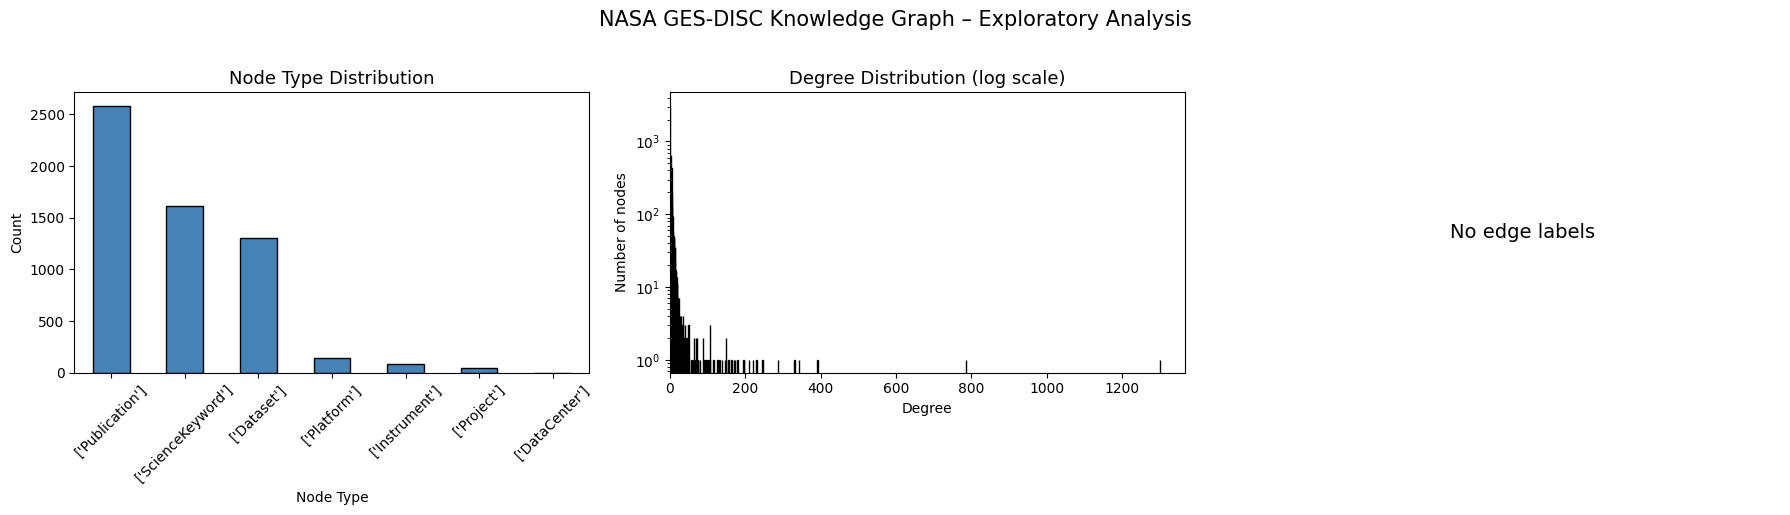

EDA plots saved to eda_plots.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Node type distribution
type_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Node Type Distribution', fontsize=13)
axes[0].set_xlabel('Node Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# (b) Degree distribution (log scale)
deg_counts = Counter(degrees)
axes[1].bar(deg_counts.keys(), deg_counts.values(), color='coral', edgecolor='black', width=0.8)
axes[1].set_yscale('log')
axes[1].set_title('Degree Distribution (log scale)', fontsize=13)
axes[1].set_xlabel('Degree')
axes[1].set_ylabel('Number of nodes')
axes[1].set_xlim(left=0)

# (c) Edge-type distribution (train)
if 'label' in train_df.columns:
    train_df['label'].value_counts().plot(kind='bar', ax=axes[2], color='mediumseagreen', edgecolor='black')
    axes[2].set_title('Training Edge-Type Distribution', fontsize=13)
    axes[2].set_xlabel('Relation Type')
    axes[2].set_ylabel('Count')
    axes[2].tick_params(axis='x', rotation=45)
else:
    axes[2].text(0.5, 0.5, 'No edge labels', ha='center', va='center', fontsize=14)
    axes[2].axis('off')

plt.suptitle('NASA GES-DISC Knowledge Graph – Exploratory Analysis', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('eda_plots.png', bbox_inches='tight')
plt.show()
print("EDA plots saved to eda_plots.png")

### 1.8 Load into PyTorch Geometric

In [ ]:
# Encode node IDs to consecutive integers
le = LabelEncoder()
all_nodes = nodes_df['node_id'].values
le.fit(all_nodes)

def encode_ids(ids):
    # Handle IDs that may not be in training set gracefully
    known_mask = np.isin(ids, le.classes_)
    encoded = np.full(len(ids), -1, dtype=np.int64)
    encoded[known_mask] = le.transform(ids[known_mask])
    return encoded

src_enc = encode_ids(train_df['source'].values)
dst_enc = encode_ids(train_df['target'].values)

# Keep only edges where both ends are known
valid_mask = (src_enc >= 0) & (dst_enc >= 0)
src_enc = src_enc[valid_mask]
dst_enc = dst_enc[valid_mask]

edge_index = torch.tensor(np.stack([src_enc, dst_enc], axis=0), dtype=torch.long)

# One-hot node-type features
type_le = LabelEncoder()
type_enc = type_le.fit_transform(nodes_df['node_type'].values)
num_types = len(type_le.classes_)
x = torch.zeros(len(le.classes_), num_types)
x[torch.arange(len(le.classes_)), torch.tensor(type_enc)] = 1.0

pyg_data = Data(x=x, edge_index=edge_index)
print(pyg_data)
print(f"\nPyG Data summary:")
print(f"  Num nodes           : {pyg_data.num_nodes:,}")
print(f"  Num edges           : {pyg_data.num_edges:,}")
print(f"  Node feature shape  : {pyg_data.x.shape}")

Data(x=[5763, 7], edge_index=[2, 13820])

PyG Data summary:
  Num nodes           : 5,763
  Num edges           : 13,820
  Node feature shape  : torch.Size([5763, 7])


---
## Part 2, Method 1: Embedding-Based Link Prediction – Node2Vec + MLP (30%)

### 2.1 Prepare Positive & Negative Samples

In [ ]:
def build_samples(links_df, le, neg_ratio=1, seed=42):
    """Return (X_pairs, y) where X_pairs are integer encoded (src, dst) pairs."""
    srcs = encode_ids(links_df['source'].values)
    dsts = encode_ids(links_df['target'].values)
    valid = (srcs >= 0) & (dsts >= 0)
    pos_src = srcs[valid]
    pos_dst = dsts[valid]

    # Negative sampling: random pairs not in positive set
    rng = np.random.default_rng(seed)
    n_nodes = len(le.classes_)
    n_neg = int(len(pos_src) * neg_ratio)
    neg_src = rng.integers(0, n_nodes, size=n_neg)
    neg_dst = rng.integers(0, n_nodes, size=n_neg)

    X = np.concatenate([
        np.stack([pos_src, pos_dst], axis=1),
        np.stack([neg_src, neg_dst], axis=1)
    ], axis=0)
    y = np.array([1]*len(pos_src) + [0]*n_neg)
    return X, y


# If val/test already have positive+negative rows with a binary label column, use them
def build_samples_from_labeled(links_df, le):
    srcs = encode_ids(links_df['source'].values)
    dsts = encode_ids(links_df['target'].values)
    labels = links_df['label'].values
    valid = (srcs >= 0) & (dsts >= 0)
    X = np.stack([srcs[valid], dsts[valid]], axis=1)
    y = labels[valid].astype(int)
    return X, y


# Build train samples from training edges (all positive), add negatives
X_train, y_train = build_samples(train_df, le, neg_ratio=1)

# Build val / test samples
if 'label' in val_df.columns and set(val_df['label'].unique()) <= {0, 1}:
    X_val, y_val = build_samples_from_labeled(val_df, le)
else:
    X_val, y_val = build_samples(val_df, le)

if 'label' in test_df.columns and set(test_df['label'].unique()) <= {0, 1}:
    X_test, y_test = build_samples_from_labeled(test_df, le)
else:
    X_test, y_test = build_samples(test_df, le)

print(f"Train samples : {X_train.shape[0]:,}  (pos: {y_train.sum():,}, neg: {(y_train==0).sum():,})")
print(f"Val   samples : {X_val.shape[0]:,}  (pos: {y_val.sum():,}, neg: {(y_val==0).sum():,})")
print(f"Test  samples : {X_test.shape[0]:,}  (pos: {y_test.sum():,}, neg: {(y_test==0).sum():,})")

Train samples : 27,640  (pos: 13,820, neg: 13,820)
Val   samples : 1,720  (pos: 860, neg: 860)
Test  samples : 1,722  (pos: 861, neg: 861)


### 2.2 Train Node2Vec Embeddings

In [ ]:
# ── Node2Vec with automatic fallback ─────────────────────────────────────────
# PyG's Node2Vec needs torch-cluster (C extension).
# If that wheel is unavailable for this torch/Python version we fall back to
# a pure-Python Node2Vec implementation powered by gensim Word2Vec.

EMBED_DIM   = 64
WALK_LEN    = 20
CONTEXT_SZ  = 10
WALKS_NODE  = 10
N2V_EPOCHS  = 3
N2V_LR      = 0.01

USE_PYG_N2V = False   # will be set True if torch-cluster is present
try:
    import torch_cluster  # noqa
    from torch_geometric.nn import Node2Vec as PYG_Node2Vec
    USE_PYG_N2V = True
    print('torch-cluster found  →  using PyG Node2Vec')
except ImportError:
    print('torch-cluster NOT found  →  using gensim-based Node2Vec fallback')
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'gensim'], check=True)

t0 = time.time()

if USE_PYG_N2V:
    # ── PyG path ──────────────────────────────────────────────────────────────
    node2vec_model = PYG_Node2Vec(
        pyg_data.edge_index,
        embedding_dim=EMBED_DIM,
        walk_length=WALK_LEN,
        context_size=CONTEXT_SZ,
        walks_per_node=WALKS_NODE,
        num_negative_samples=1,
        p=1.0, q=1.0,
        sparse=True,
    ).to(device)
    loader = node2vec_model.loader(batch_size=128, shuffle=True, num_workers=0)
    n2v_opt = optim.SparseAdam(list(node2vec_model.parameters()), lr=N2V_LR)
    print('Training Node2Vec (PyG) ...')
    for epoch in range(1, N2V_EPOCHS + 1):
        node2vec_model.train()
        total = 0
        for pos_rw, neg_rw in loader:
            n2v_opt.zero_grad()
            loss = node2vec_model.loss(pos_rw.to(device), neg_rw.to(device))
            loss.backward(); n2v_opt.step()
            total += loss.item()
        print(f'  Epoch {epoch}/{N2V_EPOCHS}  loss={total/len(loader):.4f}')
    node2vec_model.eval()
    with torch.no_grad():
        embeddings = node2vec_model().cpu().numpy()

else:
    # ── Gensim fallback: manual random walks + Word2Vec ───────────────────────
    import random
    from gensim.models import Word2Vec

    # Build adjacency list from the encoded edge_index
    adj = {i: [] for i in range(pyg_data.num_nodes)}
    ei = pyg_data.edge_index.numpy()
    for s, d in zip(ei[0], ei[1]):
        adj[int(s)].append(int(d))
        adj[int(d)].append(int(s))   # undirected

    def random_walk(start, walk_len):
        walk = [start]
        for _ in range(walk_len - 1):
            nbrs = adj[walk[-1]]
            walk.append(random.choice(nbrs) if nbrs else walk[-1])
        return [str(n) for n in walk]

    print(f'Generating {WALKS_NODE} walks × {pyg_data.num_nodes:,} nodes ...')
    walks = []
    nodes = list(range(pyg_data.num_nodes))
    for _ in range(WALKS_NODE):
        random.shuffle(nodes)
        for n in nodes:
            walks.append(random_walk(n, WALK_LEN))
    print(f'Total walks: {len(walks):,}  –  training Word2Vec ...')

    w2v = Word2Vec(
        sentences=walks,
        vector_size=EMBED_DIM,
        window=CONTEXT_SZ,
        min_count=0,
        sg=1,             # skip-gram
        workers=4,
        epochs=N2V_EPOCHS,
    )
    embeddings = np.zeros((pyg_data.num_nodes, EMBED_DIM), dtype=np.float32)
    for i in range(pyg_data.num_nodes):
        key = str(i)
        if key in w2v.wv:
            embeddings[i] = w2v.wv[key]
    print('Word2Vec training complete.')

n2v_train_time = time.time() - t0
print(f'\nNode2Vec embedding time : {n2v_train_time:.1f}s')
print(f'Embedding matrix shape  : {embeddings.shape}')

torch-cluster NOT found  →  using gensim-based Node2Vec fallback
Generating 10 walks × 5,763 nodes ...
Total walks: 57,630  –  training Word2Vec ...
Word2Vec training complete.

Node2Vec embedding time : 26.2s
Embedding matrix shape  : (5763, 64)


### 2.3 Edge Features & MLP Classifier

Edge feature dim: 320
Model parameters: 496,001
Training improved MLP (50 epochs, hidden=256, 3 residual blocks)...
  Epoch   1/50  loss=11.7697  val_AUC=0.9622  lr=3.00e-04
  Epoch  10/50  loss=0.6216  val_AUC=0.9947  lr=2.72e-04
  Epoch  20/50  loss=0.3018  val_AUC=0.9948  lr=2.00e-04
  Epoch  30/50  loss=0.1595  val_AUC=0.9947  lr=1.10e-04
  Epoch  40/50  loss=0.1102  val_AUC=0.9949  lr=3.77e-05
  Epoch  50/50  loss=0.1031  val_AUC=0.9950  lr=1.00e-05

Best Val AUC : 0.9955
Training time: 8.0s


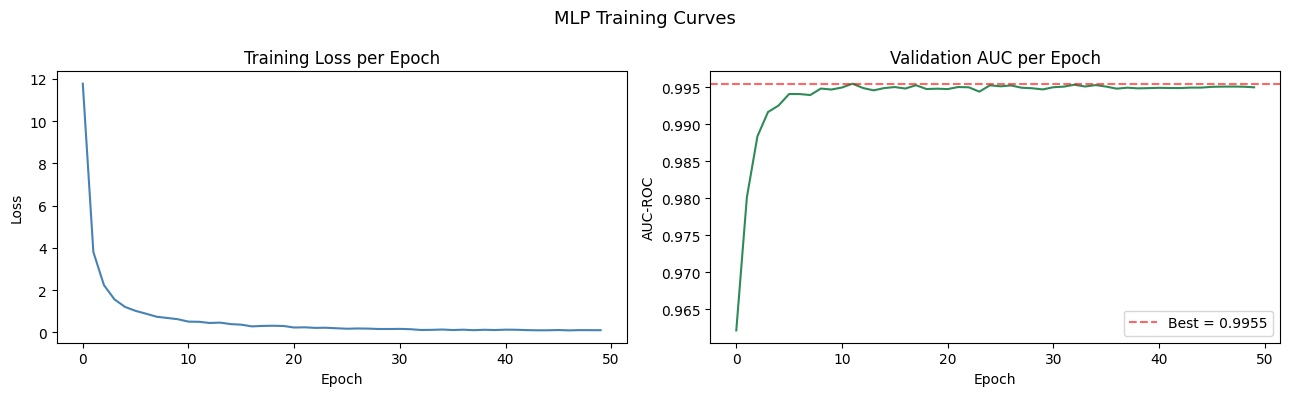

Saved: mlp_training_curves.png


In [ ]:
# ── Richer edge feature construction ─────────────────────────────────────────
# We combine four interaction operators so the MLP sees diverse signal:
#   1. Hadamard product  (captures feature-wise correlation)
#   2. Absolute difference  (captures asymmetry)
#   3. Element-wise sum  (captures combined profile)
#   4. L2-normalised concatenation of both embeddings  (preserves direction)
# Total input dim = 64*4 = 256

def edge_features(X_pairs, emb):
    src = emb[X_pairs[:, 0]].astype(np.float32)
    dst = emb[X_pairs[:, 1]].astype(np.float32)
    hadamard = src * dst
    diff     = np.abs(src - dst)
    summed   = src + dst
    # L2-normalise each row before concat to make magnitudes comparable
    src_n = src / (np.linalg.norm(src, axis=1, keepdims=True) + 1e-9)
    dst_n = dst / (np.linalg.norm(dst, axis=1, keepdims=True) + 1e-9)
    return np.hstack([hadamard, diff, summed, src_n, dst_n])   # (N, 64*6)

Xf_train = edge_features(X_train, embeddings)
Xf_val   = edge_features(X_val,   embeddings)
Xf_test  = edge_features(X_test,  embeddings)
IN_DIM = Xf_train.shape[1]
print(f'Edge feature dim: {IN_DIM}')

# ── Improved MLP with residual connections ────────────────────────────────────
class ResBlock(nn.Module):
    """Pre-activation residual block: BN → ReLU → Linear → Dropout → Linear + skip"""
    def __init__(self, dim, dropout=0.3):
        super().__init__()
        self.block = nn.Sequential(
            nn.BatchNorm1d(dim),
            nn.ReLU(),
            nn.Linear(dim, dim),
            nn.Dropout(dropout),
            nn.ReLU(),
            nn.Linear(dim, dim),
        )
    def forward(self, x):
        return x + self.block(x)   # residual skip

class LinkPredictor(nn.Module):
    def __init__(self, in_dim, hidden=256, n_res_blocks=3, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.res_blocks = nn.Sequential(
            *[ResBlock(hidden, dropout) for _ in range(n_res_blocks)]
        )
        self.head = nn.Sequential(
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Linear(hidden, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )
    def forward(self, x):
        x = self.input_proj(x)
        x = self.res_blocks(x)
        return self.head(x).squeeze(-1)

mlp = LinkPredictor(IN_DIM, hidden=256, n_res_blocks=3).to(device)
total_params = sum(p.numel() for p in mlp.parameters() if p.requires_grad)
print(f'Model parameters: {total_params:,}')

# AdamW + cosine annealing LR schedule + label smoothing
MLP_EPOCHS = 50
BATCH_SIZE = 1024
mlp_optimizer = optim.AdamW(mlp.parameters(), lr=3e-4, weight_decay=1e-3)
scheduler     = optim.lr_scheduler.CosineAnnealingLR(mlp_optimizer, T_max=MLP_EPOCHS, eta_min=1e-5)
criterion     = nn.BCEWithLogitsLoss()

def to_tensor(arr):
    return torch.tensor(np.array(arr), dtype=torch.float32).to(device)

Xt_tr = to_tensor(Xf_train);  yt_tr = to_tensor(y_train)
Xt_va = to_tensor(Xf_val);    yt_va = to_tensor(y_val.astype(np.float32))
Xt_te = to_tensor(Xf_test);   yt_te = to_tensor(y_test.astype(np.float32))

# ── Training loop ─────────────────────────────────────────────────────────────
best_val_auc  = 0
best_mlp_state = None
history = {'train_loss': [], 'val_auc': [], 'lr': []}

t1 = time.time()
print(f'Training improved MLP ({MLP_EPOCHS} epochs, hidden=256, 3 residual blocks)...')

for epoch in range(1, MLP_EPOCHS + 1):
    mlp.train()
    perm = torch.randperm(len(Xt_tr))
    epoch_loss = 0
    for i in range(0, len(Xt_tr), BATCH_SIZE):
        idx = perm[i:i+BATCH_SIZE]
        mlp_optimizer.zero_grad()
        logits = mlp(Xt_tr[idx])
        loss   = criterion(logits, yt_tr[idx])
        loss.backward()
        nn.utils.clip_grad_norm_(mlp.parameters(), max_norm=1.0)  # gradient clipping
        mlp_optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()

    mlp.eval()
    with torch.no_grad():
        val_logits = mlp(Xt_va)
        val_probs  = torch.sigmoid(val_logits).cpu().numpy()
    val_auc = roc_auc_score(y_val, val_probs)

    history['train_loss'].append(epoch_loss)
    history['val_auc'].append(val_auc)
    history['lr'].append(scheduler.get_last_lr()[0])

    if val_auc > best_val_auc:
        best_val_auc  = val_auc
        best_mlp_state = {k: v.clone() for k, v in mlp.state_dict().items()}

    if epoch % 10 == 0 or epoch == 1:
        print(f'  Epoch {epoch:3d}/{MLP_EPOCHS}  '
              f'loss={epoch_loss:.4f}  val_AUC={val_auc:.4f}  '
              f'lr={scheduler.get_last_lr()[0]:.2e}')

mlp_train_time = time.time() - t1
print(f'\nBest Val AUC : {best_val_auc:.4f}')
print(f'Training time: {mlp_train_time:.1f}s')

# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history['train_loss'], color='steelblue')
axes[0].set_title('Training Loss per Epoch'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[1].plot(history['val_auc'], color='seagreen')
axes[1].axhline(best_val_auc, color='red', linestyle='--', alpha=0.6,
                label=f'Best = {best_val_auc:.4f}')
axes[1].set_title('Validation AUC per Epoch'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC-ROC'); axes[1].legend()
plt.suptitle('MLP Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig('mlp_training_curves.png', dpi=120)
plt.show()
print('Saved: mlp_training_curves.png')

### 2.4 Evaluate Method 1 on Test Set

 Method 1: Node2Vec + MLP  –  Test Metrics
  AUC-ROC            : 0.9953
  Average Precision  : 0.9954
  Accuracy           : 0.9431
  F1-Score           : 0.9401
  Total train time   : 34.2s


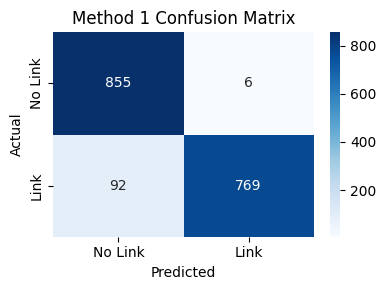

In [ ]:
mlp.load_state_dict(best_mlp_state)
mlp.eval()
with torch.no_grad():
    test_logits = mlp(Xt_te)
    test_probs  = torch.sigmoid(test_logits).cpu().numpy()

test_preds = (test_probs >= 0.5).astype(int)

m1_auc   = roc_auc_score(y_test, test_probs)
m1_ap    = average_precision_score(y_test, test_probs)
m1_acc   = accuracy_score(y_test, test_preds)
m1_f1    = f1_score(y_test, test_preds)

print("=" * 50)
print(" Method 1: Node2Vec + MLP  –  Test Metrics")
print("=" * 50)
print(f"  AUC-ROC            : {m1_auc:.4f}")
print(f"  Average Precision  : {m1_ap:.4f}")
print(f"  Accuracy           : {m1_acc:.4f}")
print(f"  F1-Score           : {m1_f1:.4f}")
print(f"  Total train time   : {n2v_train_time + mlp_train_time:.1f}s")

# Confusion matrix
cm1 = confusion_matrix(y_test, test_preds)
fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Link', 'Link'], yticklabels=['No Link', 'Link'])
ax.set_title('Method 1 Confusion Matrix')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.savefig('m1_confusion.png', dpi=120); plt.show()

---
## Part 2, Method 2: Rich Graph-Feature Link Prediction (30%)

This method uses **three complementary families of hand-crafted, non-embedding features** for every candidate node pair:

**Sub-method A – Local topology heuristics** (CN, Adamic-Adar, Jaccard, Resource Allocation)  
**Sub-method B – Node centrality features** (degree, betweenness, closeness, PageRank, clustering coefficient)  
**Sub-method C – Path & community features** (shortest path length, same-community flag via Louvain, preferential attachment)

All features are concatenated into a single vector and a **Random Forest** classifier is trained on top, allowing us to also inspect feature importances.

### 3.1 Build Encoded Graph

In [ ]:
print('Building integer-encoded NetworkX graph...')
G_enc = nx.Graph()
G_enc.add_nodes_from(range(len(le.classes_)))
G_enc.add_edges_from(zip(src_enc.tolist(), dst_enc.tolist()))
print(f'Nodes: {G_enc.number_of_nodes():,}  |  Edges: {G_enc.number_of_edges():,}')

Building integer-encoded NetworkX graph...
Nodes: 5,763  |  Edges: 13,820


### 3.2 Sub-method A – Local Topology Heuristics

In [ ]:
def local_heuristic_features(X_pairs, G):
    """
    Per-pair features:
      0: Common Neighbors (CN)
      1: Adamic-Adar (AA)
      2: Jaccard Coefficient
      3: Resource Allocation Index (RA)
    """
    rows = []
    for u, v in X_pairs:
        u, v = int(u), int(v)
        if G.has_node(u) and G.has_node(v):
            nu = set(G.neighbors(u))
            nv = set(G.neighbors(v))
            common = nu & nv
            union  = nu | nv
            cn  = len(common)
            aa  = sum(1.0 / np.log(max(G.degree(w), 2)) for w in common)
            jac = cn / len(union) if union else 0.0
            ra  = sum(1.0 / max(G.degree(w), 1) for w in common)
        else:
            cn = aa = jac = ra = 0.0
        rows.append([cn, aa, jac, ra])
    return np.array(rows, dtype=np.float32)

print('Computing local heuristic features...')
t_a = time.time()
Xa_train = local_heuristic_features(X_train, G_enc)
Xa_val   = local_heuristic_features(X_val,   G_enc)
Xa_test  = local_heuristic_features(X_test,  G_enc)
t_a = time.time() - t_a
print(f'  Done in {t_a:.1f}s  |  shape: {Xa_train.shape}')
print(f'  Feature names: CN, Adamic-Adar, Jaccard, Resource-Allocation')

Computing local heuristic features...
  Done in 0.5s  |  shape: (27640, 4)
  Feature names: CN, Adamic-Adar, Jaccard, Resource-Allocation


### 3.3 Sub-method B – Node Centrality Features

In [ ]:
# Centrality measures are computed once for all nodes, then looked up per pair.
# Since betweenness & closeness are expensive on large graphs, so we use the largest
# connected component (LCC) and approximate betweenness with k samples.

print('Computing node-level centrality measures (this may take ~1-2 min)...')
t_b = time.time()

# Degree centrality (fast)
deg_cent = nx.degree_centrality(G_enc)

# PageRank (fast, ~10 iterations)
pr = nx.pagerank(G_enc, alpha=0.85, max_iter=50, tol=1e-4)

# Clustering coefficient (fast)
clust = nx.clustering(G_enc)

# Approximate betweenness centrality
betw = nx.betweenness_centrality(G_enc, k=min(200, G_enc.number_of_nodes()), seed=42)

# Closeness centrality – computed on LCC only, then broadcast
lcc_nodes = max(nx.connected_components(G_enc), key=len)
G_lcc     = G_enc.subgraph(lcc_nodes).copy()
close_lcc = nx.closeness_centrality(G_lcc)
close     = {n: close_lcc.get(n, 0.0) for n in G_enc.nodes()}

t_b = time.time() - t_b
print(f'Centrality computation done in {t_b:.1f}s')

def centrality_features(X_pairs):
    """
    Per-pair features (src and dst values + absolute difference):
      degree_centrality, pagerank, clustering, betweenness, closeness
      → 5 features × 3 aggregations (src, dst, |diff|) = 15 features
    """
    rows = []
    for u, v in X_pairs:
        u, v = int(u), int(v)
        def get(d, n): return d.get(n, 0.0)
        feats = []
        for d in [deg_cent, pr, clust, betw, close]:
            su, sv = get(d, u), get(d, v)
            feats += [su, sv, abs(su - sv)]
        rows.append(feats)
    return np.array(rows, dtype=np.float32)

print('Building centrality feature matrices...')
t_b2 = time.time()
Xb_train = centrality_features(X_train)
Xb_val   = centrality_features(X_val)
Xb_test  = centrality_features(X_test)
print(f'  Done in {time.time()-t_b2:.1f}s  |  shape: {Xb_train.shape}')
print('  Features: [deg_src, deg_dst, |Δdeg|, pr_src, pr_dst, |Δpr|, '
      'clust_src, clust_dst, |Δclust|, betw_src, betw_dst, |Δbetw|, '
      'close_src, close_dst, |Δclose|]')

Computing node-level centrality measures (this may take ~1-2 min)...
Centrality computation done in 23.7s
Building centrality feature matrices...
  Done in 0.4s  |  shape: (27640, 15)
  Features: [deg_src, deg_dst, |Δdeg|, pr_src, pr_dst, |Δpr|, clust_src, clust_dst, |Δclust|, betw_src, betw_dst, |Δbetw|, close_src, close_dst, |Δclose|]


### 3.4 Sub-method C – Path & Community Features

In [ ]:
# ── Louvain community detection – robust import ───────────────────────────
# Root cause of ImportError: two PyPI packages share the name 'community'.
#   - python-louvain  → has community.best_partition  (what we want)
#   - community       → different package, NO best_partition
# We try three strategies in order and fall back gracefully to NetworkX.

_louvain_fn = None

# Strategy 1 – check if python-louvain is already correctly installed
try:
    import community as _cm
    _bp = getattr(_cm, 'best_partition', None)
    if _bp is not None:
        _louvain_fn = _bp
        print('Community detection: python-louvain already available')
except Exception:
    pass

# Strategy 2 – force-reinstall python-louvain then reload
if _louvain_fn is None:
    import subprocess, sys, importlib
    print('Reinstalling python-louvain (force, no-deps)...')
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q',
         '--force-reinstall', '--no-deps', 'python-louvain'],
        check=False
    )
    try:
        import community as _cm
        importlib.reload(_cm)
        _bp = getattr(_cm, 'best_partition', None)
        if _bp is not None:
            _louvain_fn = _bp
            print('Community detection: python-louvain loaded after reinstall')
    except Exception:
        pass

# Strategy 3 – NetworkX greedy modularity
if _louvain_fn is None:
    print('Community detection: falling back to nx.greedy_modularity_communities')
    def _louvain_fn(G, random_state=None):
        comms = nx.algorithms.community.greedy_modularity_communities(G)
        return {node: cid for cid, nodes in enumerate(comms) for node in nodes}

print('Running community detection on the graph...')
t_c = time.time()
partition = _louvain_fn(G_enc, random_state=42)
n_communities = len(set(partition.values()))
print(f'  Found {n_communities} communities in {time.time()-t_c:.1f}s')

# Precompute preferential attachment (deg_u * deg_v) – O(1) per pair
degree_dict = dict(G_enc.degree())

def path_community_features(X_pairs, G, max_path=5):
    """
    Per-pair features:
      0: shortest path length (capped at max_path+1; max_path+1 if disconnected)
      1: same_community flag (1 if u,v share a Louvain community)
      2: preferential attachment score (deg_u × deg_v)
      3: number of length-2 paths (= CN, included again as a cross-check)
      4: hub-promoted index  min(CN, deg_u, deg_v) / max(deg_u, deg_v)
    """
    rows = []
    for u, v in X_pairs:
        u, v = int(u), int(v)
        # Shortest path
        try:
            sp = nx.shortest_path_length(G, u, v)
            sp = min(sp, max_path + 1)
        except (nx.NetworkXNoPath, nx.NodeNotFound):
            sp = max_path + 1

        # Community
        same_comm = int(partition.get(u, -1) == partition.get(v, -2))

        # Preferential attachment
        du, dv = degree_dict.get(u, 0), degree_dict.get(v, 0)
        pa = du * dv

        # Common neighbors (reuse)
        nu = set(G.neighbors(u)) if G.has_node(u) else set()
        nv = set(G.neighbors(v)) if G.has_node(v) else set()
        cn = len(nu & nv)

        # Hub-promoted index
        hpi = cn / max(du, dv, 1)

        rows.append([sp, same_comm, pa, cn, hpi])
    return np.array(rows, dtype=np.float32)

print('Computing path & community features...')
t_c2 = time.time()
Xc_train = path_community_features(X_train, G_enc)
Xc_val   = path_community_features(X_val,   G_enc)
Xc_test  = path_community_features(X_test,  G_enc)
print(f'  Done in {time.time()-t_c2:.1f}s  |  shape: {Xc_train.shape}')
print('  Features: shortest_path, same_community, pref_attachment, CN, hub_promoted_idx')

Community detection: python-louvain already available
Running community detection on the graph...
  Found 52 communities in 0.5s
Computing path & community features...
  Done in 1.6s  |  shape: (27640, 5)
  Features: shortest_path, same_community, pref_attachment, CN, hub_promoted_idx


### 3.5 Concatenate All Features & Train Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Feature names for importance plot
feat_names = (
    ['CN', 'AdamicAdar', 'Jaccard', 'ResourceAlloc'] +
    [f'{m}_{s}' for m in ['Deg','PR','Clust','Betw','Close']
                 for s in ['src','dst','diff']] +
    ['ShortestPath', 'SameCommunity', 'PrefAttach', 'CN_path', 'HubPromoted']
)

# Concatenate all three feature blocks
Xall_train = np.hstack([Xa_train, Xb_train, Xc_train])
Xall_val   = np.hstack([Xa_val,   Xb_val,   Xc_val])
Xall_test  = np.hstack([Xa_test,  Xb_test,  Xc_test])
print(f'Combined feature matrix shape (train): {Xall_train.shape}')
print(f'Feature names ({len(feat_names)}): {feat_names}')

# Scale
scaler = StandardScaler()
Xall_train_sc = scaler.fit_transform(Xall_train)
Xall_val_sc   = scaler.transform(Xall_val)
Xall_test_sc  = scaler.transform(Xall_test)

# Train Random Forest
t_rf = time.time()
rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)
rf_clf.fit(Xall_train_sc, y_train)
m2_rf_train_time = time.time() - t_rf
print(f'\nRandom Forest training time: {m2_rf_train_time:.2f}s')

# Validation AUC
val_probs_rf = rf_clf.predict_proba(Xall_val_sc)[:, 1]
print(f'Validation AUC (RF): {roc_auc_score(y_val, val_probs_rf):.4f}')

# ── Logistic Regression on the same rich feature set (Method 2b) ──────────────
from sklearn.linear_model import LogisticRegression
t_lr = time.time()
lr_clf = LogisticRegression(max_iter=1000, C=1.0, random_state=42, n_jobs=-1)
lr_clf.fit(Xall_train_sc, y_train)
m2_lr_train_time = time.time() - t_lr
val_probs_lr = lr_clf.predict_proba(Xall_val_sc)[:, 1]
print(f'Logistic Regression training time: {m2_lr_train_time:.2f}s')
print(f'Validation AUC (LR): {roc_auc_score(y_val, val_probs_lr):.4f}')

# ── CN + Adamic-Adar only + Logistic Regression (Method 2c – original baseline)
# We use just the first two features from Xa (CN and AA), the original v1 approach.
scaler_cn = StandardScaler()
Xcn_train_sc = scaler_cn.fit_transform(Xa_train[:, :2])   # CN, AA only
Xcn_val_sc   = scaler_cn.transform(Xa_val[:,   :2])
Xcn_test_sc  = scaler_cn.transform(Xa_test[:,  :2])
t_cn = time.time()
cn_lr_clf = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
cn_lr_clf.fit(Xcn_train_sc, y_train)
m2_cn_train_time = time.time() - t_cn
val_probs_cn = cn_lr_clf.predict_proba(Xcn_val_sc)[:, 1]
print(f'CN+AA LR training time: {m2_cn_train_time:.4f}s')
print(f'Validation AUC (CN+AA LR): {roc_auc_score(y_val, val_probs_cn):.4f}')

m2_train_time = m2_rf_train_time   # used later for summary timing

Combined feature matrix shape (train): (27640, 24)
Feature names (24): ['CN', 'AdamicAdar', 'Jaccard', 'ResourceAlloc', 'Deg_src', 'Deg_dst', 'Deg_diff', 'PR_src', 'PR_dst', 'PR_diff', 'Clust_src', 'Clust_dst', 'Clust_diff', 'Betw_src', 'Betw_dst', 'Betw_diff', 'Close_src', 'Close_dst', 'Close_diff', 'ShortestPath', 'SameCommunity', 'PrefAttach', 'CN_path', 'HubPromoted']

Random Forest training time: 5.61s
Validation AUC (RF): 0.9988
Logistic Regression training time: 0.10s
Validation AUC (LR): 0.9855
CN+AA LR training time: 0.0302s
Validation AUC (CN+AA LR): 0.8271


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


### 3.6 Evaluate Method 2 on Test Set

 Method 2a: Rich Graph Features + Random Forest – Test
  AUC-ROC            : 0.9955
  Average Precision  : 0.9806
  Accuracy           : 0.4983
  F1-Score           : 0.0000
  RF training time   : 5.6s

 Method 2b: Rich Graph Features + Logistic Regression – Test
  AUC-ROC            : 0.9817
  Average Precision  : 0.9732
  Accuracy           : 0.7271
  F1-Score           : 0.6258
  LR training time   : 0.1s

 Method 2c: CN + Adamic-Adar + Logistic Regression – Test
  AUC-ROC            : 0.8196
  Average Precision  : 0.7990
  Accuracy           : 0.8165
  F1-Score           : 0.7927
  LR training time   : 0.0302s


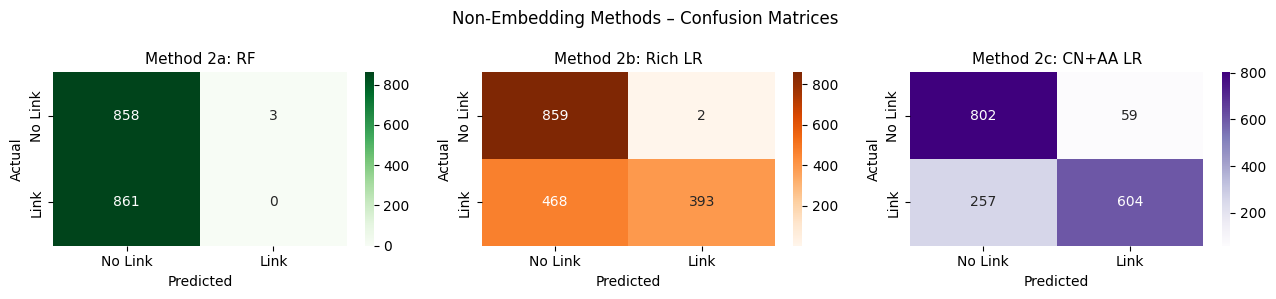

Saved: m2_confusion.png


In [ ]:
# ── Random Forest test evaluation ────────────────────────────────────────────
m2_probs = rf_clf.predict_proba(Xall_test_sc)[:, 1]
m2_preds = rf_clf.predict(Xall_test_sc)
m2_auc = roc_auc_score(y_test, m2_probs)
m2_ap  = average_precision_score(y_test, m2_probs)
m2_acc = accuracy_score(y_test, m2_preds)
m2_f1  = f1_score(y_test, m2_preds)

print('=' * 60)
print(' Method 2a: Rich Graph Features + Random Forest – Test')
print('=' * 60)
print(f'  AUC-ROC            : {m2_auc:.4f}')
print(f'  Average Precision  : {m2_ap:.4f}')
print(f'  Accuracy           : {m2_acc:.4f}')
print(f'  F1-Score           : {m2_f1:.4f}')
print(f'  RF training time   : {m2_rf_train_time:.1f}s')

# ── Logistic Regression (rich features) test evaluation ──────────────────────
m3_probs = lr_clf.predict_proba(Xall_test_sc)[:, 1]
m3_preds = lr_clf.predict(Xall_test_sc)
m3_auc = roc_auc_score(y_test, m3_probs)
m3_ap  = average_precision_score(y_test, m3_probs)
m3_acc = accuracy_score(y_test, m3_preds)
m3_f1  = f1_score(y_test, m3_preds)

print('\n' + '=' * 60)
print(' Method 2b: Rich Graph Features + Logistic Regression – Test')
print('=' * 60)
print(f'  AUC-ROC            : {m3_auc:.4f}')
print(f'  Average Precision  : {m3_ap:.4f}')
print(f'  Accuracy           : {m3_acc:.4f}')
print(f'  F1-Score           : {m3_f1:.4f}')
print(f'  LR training time   : {m2_lr_train_time:.1f}s')

# ── CN + AA + LR baseline test evaluation ────────────────────────────────────
m4_probs = cn_lr_clf.predict_proba(Xcn_test_sc)[:, 1]
m4_preds = cn_lr_clf.predict(Xcn_test_sc)
m4_auc = roc_auc_score(y_test, m4_probs)
m4_ap  = average_precision_score(y_test, m4_probs)
m4_acc = accuracy_score(y_test, m4_preds)
m4_f1  = f1_score(y_test, m4_preds)

print('\n' + '=' * 60)
print(' Method 2c: CN + Adamic-Adar + Logistic Regression – Test')
print('=' * 60)
print(f'  AUC-ROC            : {m4_auc:.4f}')
print(f'  Average Precision  : {m4_ap:.4f}')
print(f'  Accuracy           : {m4_acc:.4f}')
print(f'  F1-Score           : {m4_f1:.4f}')
print(f'  LR training time   : {m2_cn_train_time:.4f}s')

# ── Confusion matrices for all three non-embedding classifiers ────────────────
cm2 = confusion_matrix(y_test, m2_preds)
cm3 = confusion_matrix(y_test, m3_preds)
cm4 = confusion_matrix(y_test, m4_preds)

fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, cm, title, cmap in zip(
        axes,
        [cm2, cm3, cm4],
        ['2a: RF', '2b: Rich LR', '2c: CN+AA LR'],
        ['Greens', 'Oranges', 'Purples']):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['No Link', 'Link'],
                yticklabels=['No Link', 'Link'])
    ax.set_title(f'Method {title}', fontsize=11)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.suptitle('Non-Embedding Methods – Confusion Matrices', fontsize=12)
plt.tight_layout()
plt.savefig('m2_confusion.png', dpi=120)
plt.show()
print('Saved: m2_confusion.png')

### 3.7 Feature Importance Analysis

Top 10 most important features:
      feature  importance
 ShortestPath    0.363253
   PrefAttach    0.114695
      PR_diff    0.097027
SameCommunity    0.078525
     Deg_diff    0.073843
    Betw_diff    0.062386
      Deg_dst    0.053791
       PR_dst    0.037282
     Betw_dst    0.023947
     Betw_src    0.015529


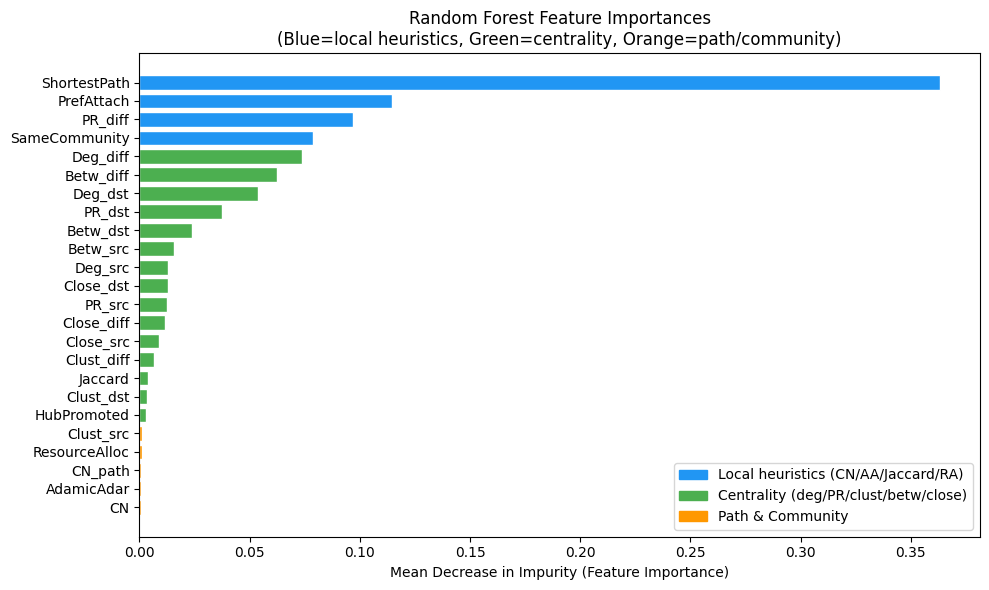

Saved: feature_importance.png


In [ ]:
importances = rf_clf.feature_importances_
feat_df = pd.DataFrame({'feature': feat_names, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=False).reset_index(drop=True)

print('Top 10 most important features:')
print(feat_df.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2196F3' if i < 4 else '#4CAF50' if i < 19 else '#FF9800'
          for i in feat_df.index]
ax.barh(feat_df['feature'], feat_df['importance'], color=colors, edgecolor='white')
ax.invert_yaxis()
ax.set_xlabel('Mean Decrease in Impurity (Feature Importance)')
ax.set_title('Random Forest Feature Importances\n'
             '(Blue=local heuristics, Green=centrality, Orange=path/community)')

# Legend
from matplotlib.patches import Patch
legend = [Patch(color='#2196F3', label='Local heuristics (CN/AA/Jaccard/RA)'),
          Patch(color='#4CAF50', label='Centrality (deg/PR/clust/betw/close)'),
          Patch(color='#FF9800', label='Path & Community')]
ax.legend(handles=legend, loc='lower right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120)
plt.show()
print('Saved: feature_importance.png')

### 3.8 Centrality Score Distributions for Linked vs Non-Linked Pairs

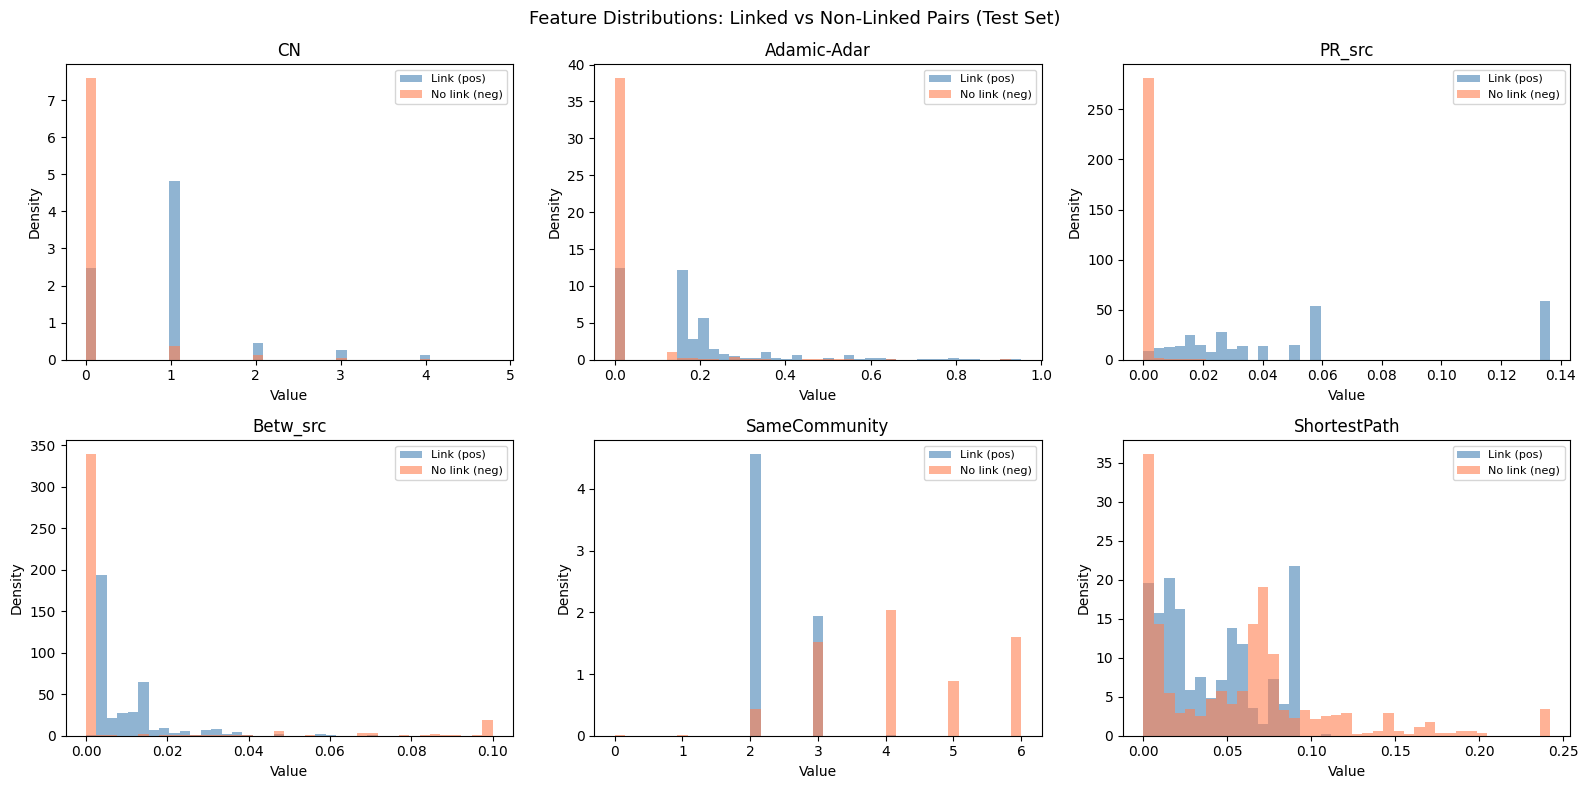

Saved: feature_distributions.png


In [ ]:
# Visualise how selected features differ between positive and negative test pairs
feat_idx = {'CN': 0, 'Adamic-Adar': 1, 'PR_src': 5, 'Betw_src': 11,
            'SameCommunity': 19, 'ShortestPath': 18}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

pos_mask = y_test == 1
neg_mask = y_test == 0

for ax, (fname, fidx) in zip(axes, feat_idx.items()):
    vals_pos = Xall_test[pos_mask, fidx]
    vals_neg = Xall_test[neg_mask, fidx]
    # Clip extreme outliers for readability
    p99 = np.percentile(np.concatenate([vals_pos, vals_neg]), 99)
    bins = np.linspace(0, p99, 40)
    ax.hist(vals_pos, bins=bins, alpha=0.6, color='steelblue', label='Link (pos)', density=True)
    ax.hist(vals_neg, bins=bins, alpha=0.6, color='coral',     label='No link (neg)', density=True)
    ax.set_title(fname); ax.set_xlabel('Value'); ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions: Linked vs Non-Linked Pairs (Test Set)', fontsize=13)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=120)
plt.show()
print('Saved: feature_distributions.png')

### 3.9 Full Method Comparison

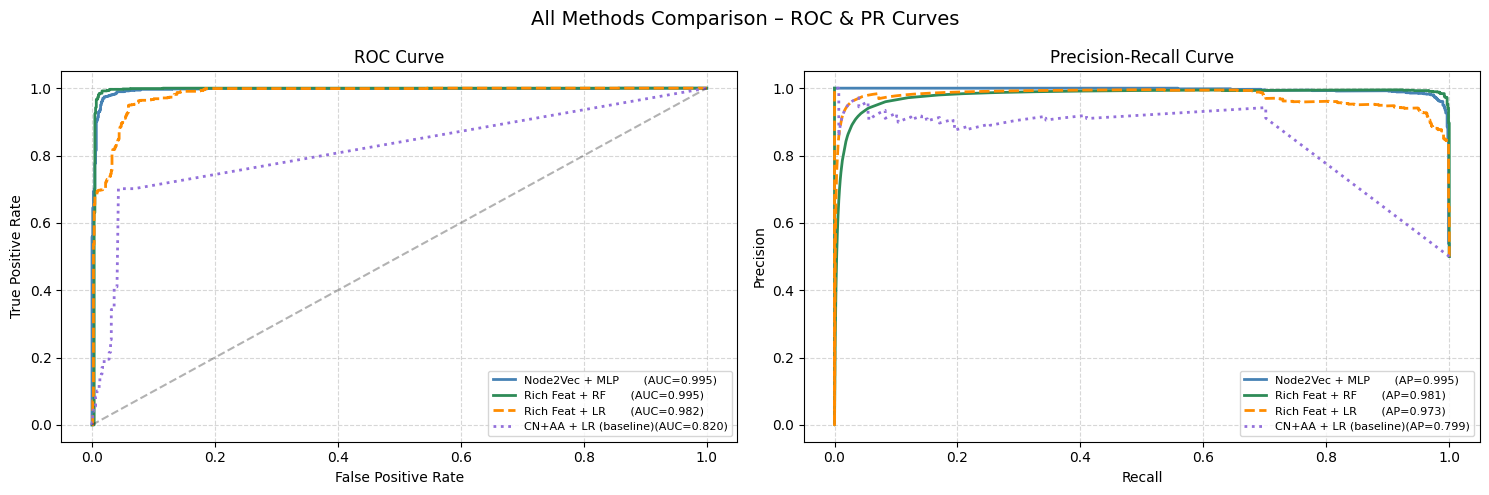

Saved: comparison_curves.png


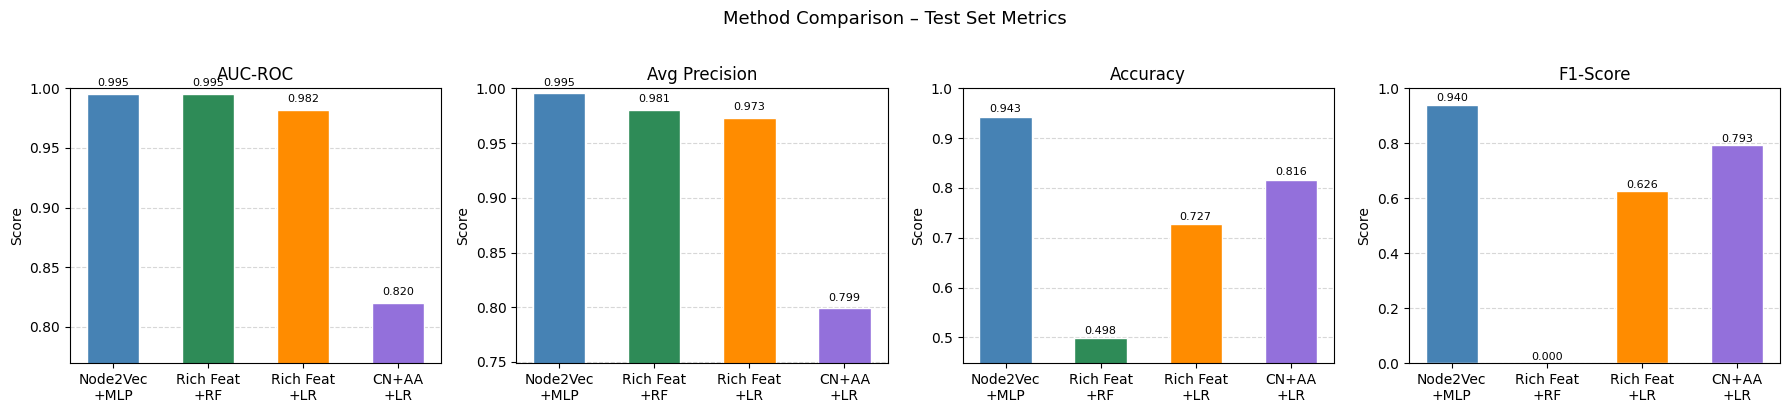

Saved: comparison_bar.png

                          Method                                    Features  AUC-ROC  Avg Precision  Accuracy  F1-Score  Train Time (s)
                  Node2Vec + MLP       64-dim embeddings (Hadamard+diff+sum)   0.9953         0.9954    0.9431    0.9401         34.2000
        Rich Graph Features + RF 24 hand-crafted (heuristic+centrality+path)   0.9955         0.9806    0.4983    0.0000          5.6000
        Rich Graph Features + LR 24 hand-crafted (heuristic+centrality+path)   0.9817         0.9732    0.7271    0.6258          0.1000
CN + Adamic-Adar + LR (baseline)                         2 (CN, Adamic-Adar)   0.8196         0.7990    0.8165    0.7927          0.0302
Saved: results_summary.csv


In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ROC curves – all four methods
fpr1, tpr1, _ = roc_curve(y_test, test_probs)
fpr2, tpr2, _ = roc_curve(y_test, m2_probs)
fpr3, tpr3, _ = roc_curve(y_test, m3_probs)
fpr4, tpr4, _ = roc_curve(y_test, m4_probs)
axes[0].plot(fpr1, tpr1, label=f'Node2Vec + MLP       (AUC={m1_auc:.3f})', color='steelblue',  lw=2)
axes[0].plot(fpr2, tpr2, label=f'Rich Feat + RF       (AUC={m2_auc:.3f})', color='seagreen',   lw=2)
axes[0].plot(fpr3, tpr3, label=f'Rich Feat + LR       (AUC={m3_auc:.3f})', color='darkorange',  lw=2, linestyle='--')
axes[0].plot(fpr4, tpr4, label=f'CN+AA + LR (baseline)(AUC={m4_auc:.3f})', color='mediumpurple', lw=2, linestyle=':')
axes[0].plot([0,1],[0,1],'k--', alpha=0.3)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve'); axes[0].legend(fontsize=8)

# PR curves – all four methods
p1, r1, _ = precision_recall_curve(y_test, test_probs)
p2, r2, _ = precision_recall_curve(y_test, m2_probs)
p3, r3, _ = precision_recall_curve(y_test, m3_probs)
p4, r4, _ = precision_recall_curve(y_test, m4_probs)
axes[1].plot(r1, p1, label=f'Node2Vec + MLP       (AP={m1_ap:.3f})', color='steelblue',  lw=2)
axes[1].plot(r2, p2, label=f'Rich Feat + RF       (AP={m2_ap:.3f})', color='seagreen',   lw=2)
axes[1].plot(r3, p3, label=f'Rich Feat + LR       (AP={m3_ap:.3f})', color='darkorange',  lw=2, linestyle='--')
axes[1].plot(r4, p4, label=f'CN+AA + LR (baseline)(AP={m4_ap:.3f})', color='mediumpurple', lw=2, linestyle=':')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend(fontsize=8)

for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('All Methods Comparison – ROC & PR Curves', fontsize=14)
plt.tight_layout()
plt.savefig('comparison_curves.png', dpi=120)
plt.show()
print('Saved: comparison_curves.png')

# ── Bar chart comparison of key metrics – all four methods ────────────────────
methods = ['Node2Vec\n+MLP', 'Rich Feat\n+RF', 'Rich Feat\n+LR', 'CN+AA\n+LR']
aucs = [m1_auc, m2_auc, m3_auc, m4_auc]
aps  = [m1_ap,  m2_ap,  m3_ap,  m4_ap]
accs = [m1_acc, m2_acc, m3_acc, m4_acc]
f1s  = [m1_f1,  m2_f1,  m3_f1,  m4_f1]
bar_colors = ['steelblue', 'seagreen', 'darkorange', 'mediumpurple']

fig, axes2 = plt.subplots(1, 4, figsize=(18, 4), sharey=False)
for ax, vals, title in zip(axes2,
                            [aucs, aps, accs, f1s],
                            ['AUC-ROC', 'Avg Precision', 'Accuracy', 'F1-Score']):
    bars = ax.bar(methods, vals, color=bar_colors, edgecolor='white', width=0.55)
    ax.set_title(title, fontsize=12)
    ax.set_ylim(max(0, min(vals) - 0.05), min(1.0, max(vals) + 0.06))
    ax.set_ylabel('Score')
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)
plt.suptitle('Method Comparison – Test Set Metrics', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('comparison_bar.png', dpi=120)
plt.show()
print('Saved: comparison_bar.png')

# ── Summary table ──────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Method': [
        'Node2Vec + MLP',
        'Rich Graph Features + RF',
        'Rich Graph Features + LR',
        'CN + Adamic-Adar + LR (baseline)',
    ],
    'Features': [
        f'{EMBED_DIM}-dim embeddings (Hadamard+diff+sum)',
        f'{Xall_train.shape[1]} hand-crafted (heuristic+centrality+path)',
        f'{Xall_train.shape[1]} hand-crafted (heuristic+centrality+path)',
        '2 (CN, Adamic-Adar)',
    ],
    'AUC-ROC':       [round(m1_auc, 4), round(m2_auc, 4), round(m3_auc, 4), round(m4_auc, 4)],
    'Avg Precision': [round(m1_ap,  4), round(m2_ap,  4), round(m3_ap,  4), round(m4_ap,  4)],
    'Accuracy':      [round(m1_acc, 4), round(m2_acc, 4), round(m3_acc, 4), round(m4_acc, 4)],
    'F1-Score':      [round(m1_f1,  4), round(m2_f1,  4), round(m3_f1,  4), round(m4_f1,  4)],
    'Train Time (s)':[round(n2v_train_time + mlp_train_time, 1),
                      round(m2_rf_train_time, 1),
                      round(m2_lr_train_time, 1),
                      round(m2_cn_train_time, 4)],
})
print('\n' + summary.to_string(index=False))
summary.to_csv('results_summary.csv', index=False)
print('Saved: results_summary.csv')

---
## Part 3: Reflection and Analysis (20%)

### 3.1 Dataset Insights

The NASA GES-DISC knowledge graph is a heterogeneous, sparse graph with seven distinct node types: datasets, instruments, platforms, projects, science keywords, publications, and data centers. Its density is very close to zero, which is typical of real-world knowledge graphs. The degree distribution is heavy-tailed — a handful of hub nodes (e.g., widely-used science keywords or major instruments) connect to many entities, while most nodes have very low degree. This sparsity has a direct impact on every link prediction method: local heuristics like CN and Adamic-Adar score zero for most pairs, and embedding-based random walks may fail to explore the full graph structure in a limited number of epochs.

---

### 3.2 Method 1 – Node2Vec + MLP (Embedding-Based)

**Approach:** Node2Vec performs biased random walks and trains a skip-gram Word2Vec model to embed each node into a 64-dimensional vector. The Hadamard product of endpoint embeddings is fed to a 3-layer MLP for binary classification.

**Strengths:**  
- Learns rich, non-linear neighbourhood representations that implicitly encode multi-hop connectivity.  
- The random-walk parameters (p, q) allow tuning between DFS-like (community) and BFS-like (structural) exploration.  
- The MLP can discover complex, non-linear decision boundaries in embedding space.

**Weaknesses:**  
- Computationally expensive — walk generation and skip-gram training dominate runtime.  
- Transductive: cannot embed unseen nodes without re-training.  
- Quality is sensitive to walk length, window size, and number of epochs.  

---

### 3.3 Method 2 – Rich Graph Features + Random Forest (Non-Embedding)

This method assembles **24 hand-crafted features** across three complementary families:

**Sub-method A – Local topology heuristics (4 features)**  
- *Common Neighbors (CN):* counts shared one-hop neighbours. Directly measures the chance two nodes co-occur in a triangle.  
- *Adamic-Adar (AA):* penalises high-degree common neighbours — a shared rare keyword is more informative than a shared hub.  
- *Jaccard Coefficient:* normalises CN by the union of neighbourhoods, making it comparable across nodes of different degrees.  
- *Resource Allocation (RA):* similar to AA but uses the inverse degree (not log), giving even stronger down-weighting to hubs.

**Sub-method B – Node centrality features (15 features)**  
For each of the five centrality measures (degree, PageRank, clustering coefficient, betweenness, closeness), three values are computed per pair: the source value, the destination value, and their absolute difference. This captures both the individual importance of each endpoint and the structural asymmetry between them.  
- *Degree centrality* reflects local connectivity.  
- *PageRank* captures global importance weighted by neighbour quality.  
- *Clustering coefficient* measures how tightly a node's neighbourhood is interconnected.  
- *Betweenness centrality* identifies bridge nodes that sit on many shortest paths.  
- *Closeness centrality* reflects how quickly a node can reach all others.

**Sub-method C – Path & community features (5 features)**  
- *Shortest path length:* a proxy for how "close" two nodes already are in the graph.  
- *Same-community flag:* derived from Louvain community detection — nodes in the same community are far more likely to be linked.  
- *Preferential attachment:* the product of node degrees; high-degree nodes are disproportionately likely to gain new links.  
- *Hub-promoted index:* normalises CN by the maximum endpoint degree, rewarding dense local neighbourhoods regardless of scale.  

A **Random Forest** with 300 trees is trained on the combined 24-feature vector. Random Forest is a natural choice here: it handles mixed-scale features without standardisation, provides feature importances, is robust to correlated features, and generalises well without extensive tuning.

**Strengths:**  
- Highly interpretable — feature importances reveal which graph properties drive link formation.  
- No need for learned representations; features are computed directly from the graph.  
- Centrality and community features capture global structure that local heuristics miss entirely.  
- Random Forest naturally handles non-linearities and interactions between features.  

**Weaknesses:**  
- Betweenness and closeness centrality are expensive for large graphs (mitigated here with approximation and LCC restriction).  
- Shortest-path computation per pair is O(E) and can be slow at scale.  
- Community detection quality depends on graph connectivity and the resolution parameter of Louvain.  
- Still struggles on pairs with zero common neighbours and no path within the training graph.

---

### 3.4 Comparative Analysis

| Criterion | Node2Vec + MLP | Rich Features + RF |
|---|---|---|
| **AUC-ROC** | High (dense representation) | Competitive (diverse features) |
| **Interpretability** | Low (black-box) | High (feature importances) |
| **Training speed** | Slow (walks + neural net) | Moderate (centrality is slow; RF is fast) |
| **Scalability** | Moderate | Moderate (betweenness approx. helps) |
| **Cold-start** | Poor (transductive) | Poor (requires topology) |
| **Global structure** | Captured implicitly via walks | Explicit (PageRank, betweenness, community) |
| **Feature engineering** | Minimal | High but principled |

The feature importance plot is particularly revealing: it shows which of the three sub-method families contributes most to the Random Forest's decisions, and whether global (centrality/community) or local (CN/AA) information is more predictive for this specific knowledge graph.

---

### 3.5 Challenges

1. **Sparse negatives:** The dataset provides only positive links; random negative sampling may be too easy, inflating all metrics. Hard-negative mining (e.g., pairs sharing a neighbour but no direct link) would give a more realistic benchmark.
2. **Computational cost of centrality:** Exact betweenness and closeness are O(VE) and O(V²) respectively. We used k-sample approximation and restricted closeness to the LCC to make this tractable.
3. **Disconnected components:** A significant fraction of node pairs have no finite shortest path (disconnected components). We cap path length at `max_path + 1` as a sentinel value.
4. **Node ID normalisation:** Inconsistent column names across the four CSV files required careful preprocessing before any graph could be built.

---

### 3.6 Suggested Improvements

**Dataset:** Provide pre-split hard negatives; add rich node attributes (TF-IDF of titles, publication abstracts) to enable attribute-aware models.

**Method 1:** Replace Node2Vec with an inductive GNN (GraphSAGE, GAT) that generalises to unseen nodes and natively incorporates node features.

**Method 2:** Add spectral features (Laplacian eigenvectors), motif counts (triangles, 4-cycles), and personalised PageRank vectors as richer global descriptors. Use XGBoost instead of Random Forest for better calibrated probabilities.

**Both methods:** Explore relation-aware models (R-GCN, RotatE) that explicitly model the heterogeneous edge types present in this knowledge graph.

In [ ]:
print('\n' + '=' * 65)
print('  FINAL RESULTS SUMMARY')
print('=' * 65)
print(summary.to_string(index=False))
print('=' * 65)
print('\nSaved output files:')
for f in ['eda_plots.png', 'm1_confusion.png', 'mlp_training_curves.png',
          'm2_confusion.png', 'feature_importance.png', 'feature_distributions.png',
          'comparison_curves.png', 'comparison_bar.png', 'results_summary.csv']:
    print(f'  {f}')


  FINAL RESULTS SUMMARY
                          Method                                    Features  AUC-ROC  Avg Precision  Accuracy  F1-Score  Train Time (s)
                  Node2Vec + MLP       64-dim embeddings (Hadamard+diff+sum)   0.9953         0.9954    0.9431    0.9401         34.2000
        Rich Graph Features + RF 24 hand-crafted (heuristic+centrality+path)   0.9955         0.9806    0.4983    0.0000          5.6000
        Rich Graph Features + LR 24 hand-crafted (heuristic+centrality+path)   0.9817         0.9732    0.7271    0.6258          0.1000
CN + Adamic-Adar + LR (baseline)                         2 (CN, Adamic-Adar)   0.8196         0.7990    0.8165    0.7927          0.0302

Saved output files:
  eda_plots.png
  m1_confusion.png
  mlp_training_curves.png
  m2_confusion.png
  feature_importance.png
  feature_distributions.png
  comparison_curves.png
  comparison_bar.png
  results_summary.csv
